In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="4zGCDGgIjB5Lg8TVVqSY")
project = rf.workspace("deep-nhhm8").project("my-first-project-prs1r")
version = project.version(2)
dataset = version.download("yolov9")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 125.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to My-First-Project-2 in yolov9:: 100%|██████████| 802/802 [00:00<00:00, 9017.49it/s]


In [2]:
import os

base_path = "My-First-Project-2"

for split in ["train", "valid", "test"]:
    img_dir = os.path.join(base_path, split, "images")
    lbl_dir = os.path.join(base_path, split, "labels")
    print(f"{split.capitalize()} - Images: {len(os.listdir(img_dir))}, Labels: {len(os.listdir(lbl_dir))}")

Train - Images: 345, Labels: 345
Valid - Images: 25, Labels: 25
Test - Images: 25, Labels: 25


In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 44.5 MB/s eta 0:00:00


In [4]:
from ultralytics import YOLO

model = YOLO("yolov9c.pt")  # ou "yolov9s.pt" pour une version plus légère
model.train(data="My-First-Project-2/data.yaml", epochs=50, imgsz=640)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.230 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=My-First-Project-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=F

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f6cfdb6eb40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [5]:
model.val()

Ultralytics 8.3.230 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv9c summary (fused): 156 layers, 25,320,790 parameters, 0 gradients, 102.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1039.3±298.3 MB/s, size: 37.2 KB)
val: Scanning /content/My-First-Project-2/valid/labels.cache... 25 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 25/25 52.9Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.4it/s 1.4s
                   all         25         36      0.641      0.764       0.67       0.39
       poubelle_pleine         18         27      0.511      0.778       0.68      0.424
         poubelle_vide          8          9      0.771       0.75      0.661      0.356
Speed: 9.2ms preprocess, 35.8ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to /content/runs/detect/val


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f6cbbfb7dd0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [9]:
results = model.predict("./download.jpg", save=True)
# print(results[0])


image 1/1 /content/download.jpg: 640x640 2 poubelle_vides, 48.9ms
Speed: 3.1ms preprocess, 48.9ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


In [ ]:
# from matplotlib import pyplot as plt
# plt.imshow(plt.imread("teste2.jpg"))
# plt.imshow(results)


image 1/1 /content/download.jpg: 640x640 1 poubelle_pleine, 1 poubelle_vide, 49.2ms
Speed: 3.5ms preprocess, 49.2ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


(np.float64(-0.5), np.float64(224.5), np.float64(224.5), np.float64(-0.5))

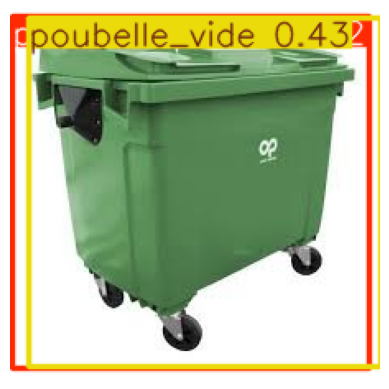

In [11]:
results = model.predict("./download.jpg", save=False)   # ou save=True si vous voulez écrire un fichier
# results = model.predict("../teste3.jpg", save=False)   # ou save=True si vous voulez écrire un fichier
img_annotated = results[0].plot()  # retourne np.array annotée (RGB)
import matplotlib.pyplot as plt
plt.imshow(img_annotated)
plt.axis('off')

In [ ]:
# Android
# model.export(format="coreml")
# web
# model.export(format="onnx")  # pour ONNX
model.export(format="tfjs")  # pour TensorFlow.js

In [8]:
# Installer les librairies nécessaires pour YOLO et Streamlit
!pip install streamlit ultralytics opencv-python-headless pillow pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 114.5 MB/s eta 0:00:00


In [9]:
%%writefile app.py
import os
import io
import tempfile
import shutil
import time
from pathlib import Path

import streamlit as st
from PIL import Image
import numpy as np
import cv2

# --- 1. Imports conditionnels et initialisation ---
try:
    from ultralytics import YOLO
    ULTRALYTICS_AVAILABLE = True
except ImportError:
    st.error("La librairie 'ultralytics' est requise. Exécutez : pip install ultralytics opencv-python-headless")
    ULTRALYTICS_AVAILABLE = False
    class YOLO:
        def __init__(self, *args, **kwargs): pass
        def predict(self, *args, **kwargs): return []

MODEL_LOCAL = Path("best.pt")

# Configuration de la page Streamlit
st.set_page_config(
    page_title="🗑️ Détecteur de Poubelles",
    page_icon="🗑️",
    layout="wide",
    initial_sidebar_state="expanded"
)

# --- CSS personnalisé optimisé pour la lisibilité ---
st.markdown("""
<style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@300;400;500;600;700&display=swap');

    /* === VARIABLES DE COULEURS === */
    :root {
        --primary-color: #2E7D32;
        --secondary-color: #1B5E20;
        --accent-color: #4CAF50;
        --danger-color: #D32F2F;
        --warning-color: #F57C00;
        --success-color: #388E3C;
        --bg-light: #F5F7FA;
        --bg-white: #FFFFFF;
        --text-dark: #1A202C;
        --text-medium: #4A5568;
        --text-light: #718096;
        --border-color: #E2E8F0;
    }

    /* === BASE === */
    html, body, [class*="st-"] {
        font-family: 'Poppins', sans-serif;
        color: var(--text-dark);
    }

    .stApp {
        background: linear-gradient(135deg, #F5F7FA 0%, #E8EEF2 100%);
    }

    /* === TITRE PRINCIPAL === */
    .main-header {
        font-size: 2.8rem;
        font-weight: 700;
        color: var(--primary-color);
        text-align: center;
        margin-bottom: 1.5rem;
        padding: 1.5rem;
        background: white;
        border-radius: 15px;
        box-shadow: 0 4px 12px rgba(0,0,0,0.08);
        animation: slideDown 0.6s ease-out;
    }

    /* === CARTES === */
    .card {
        background: var(--bg-white);
        border-radius: 12px;
        padding: 1.8rem;
        box-shadow: 0 2px 8px rgba(0,0,0,0.06);
        margin-bottom: 1.5rem;
        border: 1px solid var(--border-color);
        transition: all 0.3s ease;
    }

    .card:hover {
        box-shadow: 0 4px 16px rgba(0,0,0,0.1);
        transform: translateY(-2px);
    }

    .card h3 {
        color: var(--primary-color);
        font-size: 1.4rem;
        font-weight: 600;
        margin-bottom: 0.8rem;
    }

    .card p {
        color: var(--text-medium);
        line-height: 1.6;
        margin-bottom: 0.5rem;
    }

    /* === SOUS-TITRES === */
    .sub-header {
        font-size: 1.6rem;
        font-weight: 600;
        color: var(--secondary-color);
        margin: 2rem 0 1rem 0;
        padding-left: 1rem;
        border-left: 4px solid var(--accent-color);
    }

    /* === BADGES DE STATUT === */
    .status-badge {
        padding: 0.7rem 1.5rem;
        border-radius: 25px;
        font-weight: 600;
        font-size: 1.1rem;
        text-align: center;
        display: inline-block;
        margin: 1rem 0;
        box-shadow: 0 3px 10px rgba(0,0,0,0.15);
        animation: fadeIn 0.5s ease-in;
    }

    .status-full {
        background: linear-gradient(135deg, #D32F2F 0%, #B71C1C 100%);
        color: white;
        animation: pulse 2s infinite;
    }

    .status-empty {
        background: linear-gradient(135deg, #388E3C 0%, #2E7D32 100%);
        color: white;
    }

    .status-unknown {
        background: linear-gradient(135deg, #F57C00 0%, #EF6C00 100%);
        color: white;
    }

    /* === SECTION UPLOAD === */
    .upload-section {
        border: 2px dashed var(--accent-color);
        border-radius: 12px;
        padding: 2rem;
        text-align: center;
        background: rgba(76, 175, 80, 0.03);
        margin: 1rem 0;
        transition: all 0.3s ease;
    }

    .upload-section:hover {
        border-color: var(--primary-color);
        background: rgba(76, 175, 80, 0.08);
    }

    /* === SIDEBAR === */
    [data-testid="stSidebar"] {
        background: linear-gradient(180deg, #1B5E20 0%, #2E7D32 100%);
    }

    [data-testid="stSidebar"] * {
        color: white !important;
    }

    [data-testid="stSidebar"] .stRadio label,
    [data-testid="stSidebar"] .stCheckbox label,
    [data-testid="stSidebar"] .stSlider label {
        color: white !important;
        font-weight: 500;
    }

    [data-testid="stSidebar"] h2 {
        color: white !important;
        font-size: 1.4rem;
        padding-bottom: 0.5rem;
        border-bottom: 2px solid rgba(255,255,255,0.3);
        margin-bottom: 1rem;
    }

    [data-testid="stSidebar"] h3 {
        color: white !important;
        font-size: 1.1rem;
        margin-top: 1.5rem;
    }

    /* Sliders dans la sidebar */
    [data-testid="stSidebar"] .stSlider [data-baseweb="slider"] {
        background: rgba(255,255,255,0.2);
    }

    /* Info box dans sidebar */
    .model-info {
        background: rgba(255, 255, 255, 0.15);
        color: white;
        padding: 1rem;
        border-radius: 10px;
        margin: 1rem 0;
        border: 1px solid rgba(255,255,255,0.2);
    }

    /* === BOUTONS === */
    .stButton > button {
        background: linear-gradient(135deg, var(--accent-color) 0%, var(--primary-color) 100%);
        color: white;
        border: none;
        border-radius: 8px;
        padding: 0.7rem 1.5rem;
        font-weight: 600;
        transition: all 0.3s ease;
        box-shadow: 0 3px 8px rgba(46, 125, 50, 0.3);
    }

    .stButton > button:hover {
        transform: translateY(-2px);
        box-shadow: 0 5px 15px rgba(46, 125, 50, 0.4);
    }

    /* === BARRE DE PROGRESSION === */
    .stProgress > div > div > div > div {
        background: linear-gradient(90deg, var(--accent-color), var(--primary-color));
    }

    /* === ANIMATIONS === */
    @keyframes fadeIn {
        from { opacity: 0; }
        to { opacity: 1; }
    }

    @keyframes slideDown {
        from {
            opacity: 0;
            transform: translateY(-30px);
        }
        to {
            opacity: 1;
            transform: translateY(0);
        }
    }

    @keyframes pulse {
        0%, 100% { transform: scale(1); }
        50% { transform: scale(1.05); }
    }

    /* === EXPANDER === */
    .streamlit-expanderHeader {
        background: var(--bg-light);
        border-radius: 8px;
        font-weight: 600;
        color: var(--primary-color);
    }

    /* === DATAFRAME === */
    .stDataFrame {
        border-radius: 8px;
        overflow: hidden;
    }

    /* === MESSAGES INFO === */
    .stAlert {
        border-radius: 8px;
        border-left: 4px solid;
    }

</style>
""", unsafe_allow_html=True)

# --- Initialisation de l'état de session ---
if 'model_path' not in st.session_state:
    st.session_state.model_path = None
if 'model' not in st.session_state:
    st.session_state.model = None
if 'video_processed' not in st.session_state:
    st.session_state.video_processed = False
if 'video_frames' not in st.session_state:
    st.session_state.video_frames = []

# --- 2. Fonctions d'aide ---

@st.cache_resource(show_spinner=False)
def load_model(model_path: str):
    """Charge le modèle YOLO et le met en cache."""
    if not ULTRALYTICS_AVAILABLE:
        return None
    try:
        with st.spinner("🔄 Chargement du modèle IA..."):
            model = YOLO(model_path)
            time.sleep(1)
        return model
    except Exception as e:
        st.error(f"Échec du chargement du modèle : {e}")
        return None

def run_image_inference(model, img_path, conf=0.25, iou=0.45):
    """Effectue l'inférence sur l'image et analyse le résultat."""
    try:
        results = model.predict(source=str(img_path), conf=conf, iou=iou, save=False)

        if not results:
            st.warning("Aucune prédiction retournée par le modèle.")
            return None, None, "Aucun résultat", "status-unknown"

        r = results[0]
        annotated = r.plot()

        boxes = []
        try:
            xyxy = r.boxes.xyxy.tolist()
            confs = r.boxes.conf.tolist()
            classes = r.boxes.cls.tolist()
            names = r.names if hasattr(r, 'names') else (model.names if hasattr(model, 'names') else {})

            for b, c, cl in zip(xyxy, confs, classes):
                boxes.append({
                    "xmin": int(b[0]), "ymin": int(b[1]), "xmax": int(b[2]), "ymax": int(b[3]),
                    "conf": float(c), "class_id": int(cl), "label": names.get(int(cl), str(cl))
                })
        except Exception:
            boxes = []

        status = "Inconnu"
        status_class = "status-unknown"

        if boxes:
            classes_detected = [box['label'].lower() for box in boxes]

            if any(k in c for c in classes_detected for k in ['plein', 'full', 'filled']):
                status = '🔴 Pleine'
                status_class = "status-full"
            elif any(k in c for c in classes_detected for k in ['vide', 'empty', 'empty-bin']):
                status = '🟢 Vide'
                status_class = "status-empty"
            else:
                status = '🟡 Poubelle détectée (état incertain)'
                status_class = "status-unknown"
        else:
            status = '⚪ Aucune poubelle détectée'
            status_class = "status-unknown"

        return annotated, boxes, status, status_class

    except Exception as e:
        st.error(f"Erreur d'inférence : {e}")
        return None, None, 'Erreur', "status-unknown"

def extract_frames_from_video(video_path, max_frames=6):
    """Extrait des frames d'une vidéo pour prévisualisation."""
    frames = []
    try:
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            st.error("Impossible d'ouvrir le fichier vidéo.")
            return []

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frame_interval = max(1, total_frames // max_frames)

        frame_count = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            if frame_count % frame_interval == 0 and len(frames) < max_frames:
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frames.append(frame_rgb)

            frame_count += 1
            if len(frames) >= max_frames:
                break

        cap.release()
        return frames
    except Exception as e:
        st.error(f"Erreur lors de l'extraction des frames: {e}")
        return []

def process_video_with_progress(model, video_path, conf=0.25, iou=0.45):
    """Traite la vidéo avec une barre de progression."""

    progress_container = st.container()

    with progress_container:
        progress_bar = st.progress(0)
        status_text = st.empty()

    run_name = f"video_run_{time.time_ns()}"

    try:
        status_text.info("🔄 Démarrage du traitement vidéo...")
        progress_bar.progress(10)

        status_text.info("🔄 Analyse des frames avec l'IA...")
        progress_bar.progress(40)

        model.predict(source=str(video_path), conf=conf, iou=iou, save=True, name=run_name, exist_ok=True)

        status_text.info("🔄 Finalisation et encodage...")
        progress_bar.progress(80)

        output_dir = Path(f'runs/detect/{run_name}')
        video_out = next((p for p in output_dir.glob('*') if p.suffix.lower() in ['.mp4', '.mov', '.avi']), None)

        progress_bar.progress(100)
        progress_container.empty()

        if video_out and video_out.exists():
            return str(video_out)
        else:
            st.warning("Vidéo traitée, mais le fichier de sortie n'a pas été trouvé.")
            return None

    except Exception as e:
        st.error(f"Échec du traitement vidéo : {e}")
        progress_container.empty()
        return None

def cleanup_temp_file(path):
    """Supprime un fichier temporaire."""
    if path and Path(path).exists():
        try:
            os.unlink(path)
        except Exception:
            pass

# --- 3. Application Principale ---

def main():
    if not ULTRALYTICS_AVAILABLE:
        st.stop()

    st.markdown('<h1 class="main-header">🗑️ Détecteur Intelligent de Poubelles</h1>', unsafe_allow_html=True)

    st.markdown("""
    <div class="card">
        <h3>🎯 Bienvenue dans l'analyseur IA de poubelles</h3>
        <p>Cette application utilise un modèle <b>YOLO</b> personnalisé pour détecter et classifier automatiquement l'état de remplissage des poubelles.</p>
        <p>✨ <b>Fonctionnalités :</b> Détection en temps réel, analyse d'images et vidéos, classification Plein/Vide</p>
    </div>
    """, unsafe_allow_html=True)

    # --- Sidebar ---
    with st.sidebar:
        st.markdown('<div class="model-info">', unsafe_allow_html=True)
        st.header("⚙️ Configuration")
        st.markdown('</div>', unsafe_allow_html=True)

        model_choice = st.radio("📁 Source du modèle", ["Utiliser le modèle local", "Uploader un .pt"], key='model_src')
        uploaded_model = None

        if model_choice == "Uploader un .pt":
            uploaded_model = st.file_uploader("Charger votre modèle (.pt)", type=["pt"])

        st.markdown("---")
        st.subheader("🎚️ Paramètres de détection")
        conf_thres = st.slider("Seuil de confiance", 0.0, 1.0, 0.25, help="Niveau de confiance minimum")
        iou_thres = st.slider("Seuil NMS (IoU)", 0.0, 1.0, 0.45, help="Suppression des boîtes superposées")

        st.markdown("---")
        st.subheader("🎥 Options vidéo")
        run_on_video = st.checkbox("Activer traitement vidéo", value=False)
        show_video_frames = st.checkbox("Aperçu des frames", value=True)

        st.markdown("---")
        if st.button("🔄 Recharger le modèle", use_container_width=True):
            load_model.clear()
            st.session_state.model_path = None
            st.session_state.model = None
            st.rerun()

    # --- Chargement du Modèle ---
    new_model_path = None

    if uploaded_model is not None:
        # Si l'utilisateur upload un nouveau modèle
        with tempfile.NamedTemporaryFile(delete=False, suffix='.pt') as t:
            t.write(uploaded_model.read())
            new_model_path = t.name
        st.sidebar.success(f"✅ Modèle personnalisé chargé")
    elif MODEL_LOCAL.exists():
        # Utiliser best.pt par défaut
        new_model_path = str(MODEL_LOCAL)
    else:
        st.sidebar.error("❌ Fichier best.pt introuvable")

    if new_model_path and st.session_state.model_path != new_model_path:
        if st.session_state.model_path and "tmp" in st.session_state.model_path:
             cleanup_temp_file(st.session_state.model_path)

        st.session_state.model = load_model(new_model_path)
        st.session_state.model_path = new_model_path

    model = st.session_state.model

    if model is None:
        st.sidebar.error("❌ Modèle non chargé")
    else:
        try:
            names = getattr(model, 'names', None)
            st.sidebar.success("✅ Modèle opérationnel")
            if names:
                st.sidebar.markdown(f"**Classes :** {', '.join(names.values())}")
        except Exception:
            st.sidebar.info("ℹ️ Modèle chargé")

    # --- Analyse d'Image ---
    st.markdown('<div class="sub-header">📸 Analyse d\'Image</div>', unsafe_allow_html=True)

    # Onglets pour différentes sources d'image
    tab1, tab2 = st.tabs(["📁 Fichier", "📷 Webcam"])

    with tab1:
        col1, col2 = st.columns([1, 1])

        with col1:
            st.markdown('<div class="upload-section">', unsafe_allow_html=True)
            uploaded_image = st.file_uploader("**Téléversez une image**", type=["jpg", "jpeg", "png"], key="image_uploader")
            st.markdown('</div>', unsafe_allow_html=True)

            if uploaded_image and model:
                image = Image.open(uploaded_image)
                st.image(image, caption='Image originale', use_column_width=True)

        with col2:
            if uploaded_image and model:
                tmp_img_path = None
                with tempfile.NamedTemporaryFile(delete=False, suffix='.jpg') as t:
                    image.save(t, format='JPEG')
                    tmp_img_path = t.name

                with st.spinner("🔍 Analyse IA en cours..."):
                    annotated, boxes, status, status_class = run_image_inference(model, tmp_img_path, conf=conf_thres, iou=iou_thres)

                cleanup_temp_file(tmp_img_path)

                if annotated is not None:
                    st.markdown(f'<div class="status-badge {status_class}">{status}</div>', unsafe_allow_html=True)

                    st.markdown('<div class="card">', unsafe_allow_html=True)
                    st.image(annotated, caption='Résultat de l\'analyse', use_column_width=True)
                    st.markdown('</div>', unsafe_allow_html=True)

                    if boxes:
                        with st.expander("📊 Détails des détections", expanded=False):
                            df_boxes = [{
                                "Classe": box['label'],
                                "Confiance": f"{box['conf']:.2%}",
                                "Position": f"({box['xmin']}, {box['ymin']})"
                            } for box in boxes]
                            st.dataframe(df_boxes, hide_index=True, use_container_width=True)

                    buf = io.BytesIO()
                    Image.fromarray(annotated.astype('uint8')).save(buf, format='JPEG')
                    buf.seek(0)
                    st.download_button("💾 Télécharger le résultat", data=buf, file_name="analyse_poubelle.jpg", mime='image/jpeg', use_container_width=True)
                else:
                    st.warning("⚠️ Aucune détection au-dessus du seuil de confiance")

            elif uploaded_image and not model:
                st.error("❌ Veuillez charger un modèle")

    with tab2:
        st.markdown('<div class="card">', unsafe_allow_html=True)
        st.markdown("### 📷 Détection en temps réel via Webcam")
        st.markdown("</div>", unsafe_allow_html=True)

        col1, col2 = st.columns([1, 1])

        with col1:
            camera_image = st.camera_input("Prenez une photo", key="camera")

        with col2:
            if camera_image and model:
                image = Image.open(camera_image)

                tmp_img_path = None
                with tempfile.NamedTemporaryFile(delete=False, suffix='.jpg') as t:
                    image.save(t, format='JPEG')
                    tmp_img_path = t.name

                with st.spinner("🔍 Analyse IA en cours..."):
                    annotated, boxes, status, status_class = run_image_inference(model, tmp_img_path, conf=conf_thres, iou=iou_thres)

                cleanup_temp_file(tmp_img_path)

                if annotated is not None:
                    st.markdown(f'<div class="status-badge {status_class}">{status}</div>', unsafe_allow_html=True)

                    st.markdown('<div class="card">', unsafe_allow_html=True)
                    st.image(annotated, caption='Résultat de l\'analyse', use_column_width=True)
                    st.markdown('</div>', unsafe_allow_html=True)

                    if boxes:
                        with st.expander("📊 Détails des détections", expanded=False):
                            df_boxes = [{
                                "Classe": box['label'],
                                "Confiance": f"{box['conf']:.2%}",
                                "Position": f"({box['xmin']}, {box['ymin']})"
                            } for box in boxes]
                            st.dataframe(df_boxes, hide_index=True, use_container_width=True)

                    buf = io.BytesIO()
                    Image.fromarray(annotated.astype('uint8')).save(buf, format='JPEG')
                    buf.seek(0)
                    st.download_button("💾 Télécharger le résultat", data=buf, file_name="analyse_webcam.jpg", mime='image/jpeg', use_container_width=True, key="download_webcam")
                else:
                    st.warning("⚠️ Aucune détection au-dessus du seuil de confiance")

            elif camera_image and not model:
                st.error("❌ Veuillez charger un modèle")

    # --- Analyse Vidéo ---
    st.markdown("---")
    st.markdown('<div class="sub-header">🎥 Analyse Vidéo</div>', unsafe_allow_html=True)

    if not run_on_video:
        st.info("💡 Activez l'option dans la barre latérale pour analyser des vidéos")
    else:
        uploaded_video = st.file_uploader("Téléversez une vidéo", type=["mp4", "mov", "avi"], key="video_uploader")

        if uploaded_video:
            st.subheader("📹 Vidéo Originale")
            st.video(uploaded_video, format="video/mp4")

            if show_video_frames:
                with st.spinner("🔄 Extraction des frames..."):
                    tmp_vid_path = None
                    with tempfile.NamedTemporaryFile(delete=False, suffix=Path(uploaded_video.name).suffix) as t:
                        t.write(uploaded_video.read())
                        tmp_vid_path = t.name

                    frames = extract_frames_from_video(tmp_vid_path, max_frames=6)
                    cleanup_temp_file(tmp_vid_path)

                    if frames:
                        st.subheader("🎞 Aperçu des frames")
                        cols = st.columns(3)
                        for i, frame in enumerate(frames):
                            with cols[i % 3]:
                                st.image(frame, caption=f"Frame {i+1}", use_column_width=True)

            st.markdown("---")
            if st.button("🚀 Lancer l'analyse vidéo", use_container_width=True) and model:
                tmp_vid_path = None
                with tempfile.NamedTemporaryFile(delete=False, suffix=Path(uploaded_video.name).suffix) as t:
                    t.write(uploaded_video.getvalue())
                    tmp_vid_path = t.name

                output_video_path = process_video_with_progress(model, tmp_vid_path, conf=conf_thres, iou=iou_thres)
                cleanup_temp_file(tmp_vid_path)

                if output_video_path:
                    st.success("✅ Analyse terminée avec succès !")
                    st.subheader("📹 Vidéo Analysée")
                    st.video(output_video_path)

                    with open(output_video_path, 'rb') as f:
                        st.download_button(
                            '💾 Télécharger la vidéo analysée',
                            data=f,
                            file_name=f"analyse_{int(time.time())}.mp4",
                            mime='video/mp4',
                            use_container_width=True
                        )

            elif not model and run_on_video:
                st.error("❌ Veuillez charger un modèle")

    # --- Footer ---
    st.markdown("---")
    st.markdown("""
    <div style="text-align: center; color: #718096; padding: 2rem 0;">
        <p style="font-size: 0.95rem;">🗑️ Détecteur Intelligent de Poubelles • Propulsé par <b>YOLO</b> et <b>Streamlit</b></p>
        <p style="font-size: 0.85rem; margin-top: 0.5rem;">Pour une gestion optimale des déchets 🌍</p>
    </div>
    """, unsafe_allow_html=True)


if __name__ == '__main__':
    main()

Writing app.py


In [5]:
# Copie le modèle entraîné vers le nom attendu par l'application
!cp /content/runs/detect/train/weights/best.pt /content/best_poubelle.pt

cp: cannot stat '/content/runs/detect/train/weights/best.pt': No such file or directory


In [7]:
import os
from pyngrok import ngrok

# --- Configuration de votre jeton ngrok ---
NGROK_AUTHTOKEN = "35oC0SBPjeumprIyog1uIcBPlqA_3wUjkv9KKGbJaGahikyDA"
ngrok.set_auth_token(NGROK_AUTHTOKEN)

print("✅ Jeton ngrok configuré avec succès.")

ModuleNotFoundError: No module named 'pyngrok'

In [24]:
from pyngrok import ngrok
import threading
import time
import os

# --- VÉRIFIEZ QUE VOUS AVEZ EXÉCUTÉ LA CELLULE DE CONFIGURATION DU JETON CI-DESSUS ---

# Fermez tous les tunnels existants (pour éviter les conflits)
ngrok.kill()

# Fonction pour démarrer Streamlit
def run_streamlit():
    os.system("streamlit run app.py --server.port 8501 --server.enableCORS False --server.enableXsrfProtection False")

# Démarrer Streamlit
thread = threading.Thread(target=run_streamlit)
thread.start()

time.sleep(10) # Laisse le temps au serveur de démarrer

# Démarrez le tunnel HTTP sur le port Streamlit par défaut (8501)
try:
    public_url = ngrok.connect(8501).public_url
    print(f" 🚀 Votre application Streamlit est accessible à l'URL : {public_url}")
except Exception as e:
    print(f"Erreur lors de la création du tunnel ngrok: {e}")

 🚀 Votre application Streamlit est accessible à l'URL : https://courdinately-authorisable-sonya.ngrok-free.dev
